# Data Analysis

> **Data analysis** is the process of inspecting, cleansing, transforming, and modeling data with the goal of discovering useful information, informing conclusions, and supporting decision-making.

Two approaches to data analysis:

## A. Confirmatory Data Analysis (CDA)

A top-down approach in which we **start with a question and use data to answer it**.

Example Hypothesis: "people are addicted to smart phones". Let's see if the data supports this.

## B. Exploratory Data Analysis (EDA)

A bottom-up approach in which we **start with the data and try to find something interesting**.

Example Data: "people watching videos on our platform". Let's find out what piques their interest the most".

## Experiment: Blind Typing

An experiment aims to confirm a hypothesis using data. Hence, we are doing CDA.

In this experiment, we want to test people who claim that they type without looking at their keyboard. Let's verify their claim. The words-per-minute typed should not significantly drop if we turn off the lights.

1. We will test our typing with the **lights on**
2. Then, we'll test again with the **lights off**

Now let's jump to action..

### 1. Data Collection

- Experiment subjects will visit the website: https://monkeytype.com/ to undergo the typing test.
- Each subject will report their own score. Which we will store down below.

### 2. Data Loading

We will use regular Python lists to store the measurements before and after the intervention.

In [31]:
# Experiment Data
scores_1 = [33, 46, 35, 28, 20, 22, 19, 25, 19, 67, 23, 19, 40, 18, 27, 44]
scores_2 = [46, 23, 36, 21, 38, 23, 22, 27, 28, 37, 37, 26, 33, 53, 9, 13]

### 3. Verification

We expect the same participants to undergo the experiment once with the lights on and once with the lights out. 

In [57]:
# Quick Check
assert len(scores_1) == len(scores_2)

### 4. Transformation

In [33]:
# Concatenate
scores = scores_1 + scores_2
scores[:10]

[33, 46, 35, 28, 20, 22, 19, 25, 19, 67]

### 5. Analysis

In [34]:
def my_sum(data):
    s = 0
    for i in scores:
        s += i
    return s

my_sum(scores)

957

In [35]:
def my_average(data):
    return my_sum(data) / len(scores)

my_average(scores)

29.90625

In [36]:
def my_median(data):
    mid_index = len(scores) // 2
    return sorted(data)[mid_index]

my_median(scores)

27

In Python, libraries like Pandas include data-structures and algorithms (collectively as objects) to perform calculations efficiently on lists and tables, also known as: **Series** and **DataFrames** respectively.

### Enter: `pandas.Series`

In [37]:
import pandas as pd

s = pd.Series(scores, name="wpm")
s[:10]

0    33
1    46
2    35
3    28
4    20
5    22
6    19
7    25
8    19
9    67
Name: wpm, dtype: int64

Statistics:

In [38]:
print("Number of items:", len(s))
print("Sum:", s.sum())
print("Average:", s.mean())
print("Median:", s.median(),)
print("Mode:", s.mode()[0])
print("Standard Deviation:", s.std())

Number of items: 32
Sum: 957
Average: 29.90625
Median: 27.0
Mode: 19
Standard Deviation: 12.32191694083247


But also:

In [39]:
s.nlargest(3)

9     67
29    53
1     46
Name: wpm, dtype: int64

In [40]:
s.nsmallest(3)

30     9
31    13
13    18
Name: wpm, dtype: int64

### Enter: `pandas.DataFrame`

In [41]:
from pathlib import Path

# Load data from CSV into a DataFrame
file_path = Path("../../data/wpm.csv")
df = pd.read_csv(file_path)

In [42]:
df.head()

,wpm,light
0,11,False
1,15,False
2,50,False
3,13,False
4,15,False


In [43]:
import pandas as pd
from pathlib import Path

file_path = Path("../../data/wpm.csv")

df = pd.DataFrame({
    "wpm": scores_1 + scores_2,
    "intervention": [False] * len(scores_1) + [True] * len(scores_2)
})

df = pd.read_csv(file_path)

In [44]:
df.head()

,wpm,light
0,11,False
1,15,False
2,50,False
3,13,False
4,15,False


In [45]:
df.tail()

,wpm,light
21,21,True
22,37,True
23,42,True
24,36,True
25,40,True


> Aside: you might wonder what is `[False] * len(scores_2)`

In [46]:
x = [10, 10, 10]
x * 3

[10, 10, 10, 10, 10, 10, 10, 10, 10]

In [47]:
x = pd.Series([10, 10, 10])
x * 3

0    30
1    30
2    30
dtype: int64

In [48]:
xs = [True] * len(scores_1) + [False] * len(scores_2)

In [49]:
# head and tail
xs[:3], xs[-3:]

([True, True, True], [False, False, False])

### Overall statistics

In [50]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
wpm,26.0,29.346154,12.013134,10.0,20.25,28.0,40.0,50.0


### Statistics by group

In [51]:
# df.groupby(by='intervention').describe()
df.groupby(by='light').describe()

wpm                                                    
      count       mean        std   min   25%   50%   75%   max
light                                                          
False  13.0  26.153846  13.813316  10.0  15.0  23.0  38.0  50.0
True   13.0  32.538462   9.368523  20.0  24.0  36.0  41.0  46.0

### Visualization: `Seaborn`

**Seaborn** is a visualization library specifically built for statistical plots. We'll use it to render the **Box-and-whiskers Plot** which visualizes the statistics described in the summary table above.

<Axes: xlabel='light', ylabel='wpm'>

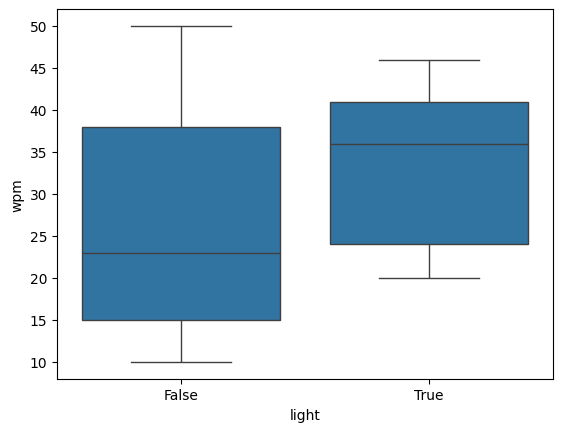

In [55]:
import seaborn as sns

sns.boxplot(
    data=df,
    y='wpm',
    # x='intervention'
    x='light'
)